# Modelo 

In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Masking, Bidirectional, Dropout
from tensorflow.keras.optimizers import Adam 
from tensorflow.keras.callbacks import EarlyStopping

Primero crearemos la LSTM Simple, posteriormente aplicaremos validacion cruzada, y por último aplicaremos validacion cruzada y ajustaremos algunos parametros    
Después haremos lo mismo eliminando los videos ruidosos 

En la segunda fase haremos crearemos una LSTM Simple con angulos articulares, después aplicaremos validacion cruzada y por último validacion cruzada ajustando parametros    
Al igual que antes, volveremos a realizar los cálculos eliminando los videos ruidosos.

Finalmente compararemos todos los modelos en una gráfica

## Coordenadas de puntos clave como datos de entrada del modelo

### Carga de datos

In [2]:
X_correct = np.load('../Data/Processed/correct_push_ups_landmarks.npy')
X_incorrect = np.load('../Data/Processed/wrong_push_ups_landmarks.npy')

X = np.vstack((X_correct, X_incorrect))
y = np.array([1]*X_correct.shape[0] + [0]*X_incorrect.shape[0])  

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
X_train.shape[1]

160

In [5]:
timesteps = X_train.shape[1]  # 160 frames (numero de frames por secuencia)
features = X_train.shape[2]   # 66 valores por frame

### LSTM Simple

In [6]:
model = Sequential()
model.add(Masking(mask_value=0., input_shape=(timesteps, features)))  # ignorar padding
model.add(LSTM(64, return_sequences=False))  # 64 unidades LSTM, solo devolvemos la última salida
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))    # salida binaria

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=35,
    batch_size=16
)

Epoch 1/35


/opt/miniconda3/envs/exml-py310/lib/python3.10/site-packages/keras/src/layers/core/masking.py:48: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.4688 - loss: 0.7132 - val_accuracy: 0.6250 - val_loss: 0.6687
Epoch 2/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5000 - loss: 0.6892 - val_accuracy: 0.6250 - val_loss: 0.6751
Epoch 3/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5469 - loss: 0.6834 - val_accuracy: 0.3750 - val_loss: 0.6863
Epoch 4/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5781 - loss: 0.6691 - val_accuracy: 0.7500 - val_loss: 0.6333
Epoch 5/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.6094 - loss: 0.6566 - val_accuracy: 0.6875 - val_loss: 0.6211
Epoch 6/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6719 - loss: 0.6308 - val_accuracy: 0.6875 - val_loss: 0.6256
Epoch 7/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6875 - loss: 0.5839 - val_accuracy: 0.6875 - val_loss: 0.5818
Epoch 8/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.7188 - loss: 0.5658 - val_accuracy: 0.8125 - val_loss: 0.5506
Epoch 9/35


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.8000 - loss: 0.6109
Test Accuracy: 0.80


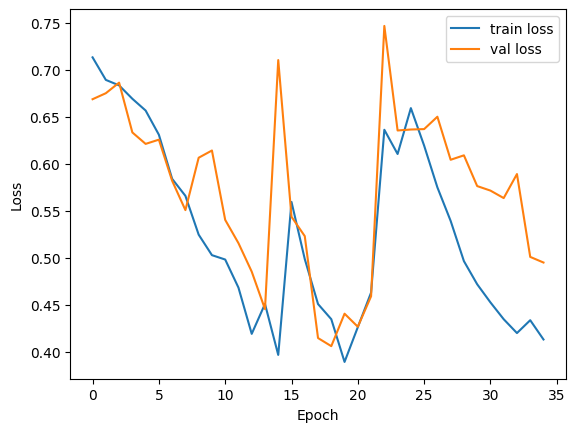

In [7]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2f}")


plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Obtenemos un buen accuracy pero con picos de inestabilidad

### Validación cruzada

#### Creación de funciones de validacion cruzada y visualización 

In [8]:
from tensorflow.keras.callbacks import EarlyStopping

# ==============================================================================
# FUNCIÓN 1: Ejecutar el Experimento de K-Fold (CON FLEXIBILIDAD)
# ==============================================================================
def run_kfold_experiment(model_fn, X_train, y_train, epochs, batch_size, n_splits=5, patience=None):
    """
    Ejecuta la validación cruzada K-Fold y devuelve métricas e historias.
    
    Args:
        model_fn: Función que devuelve un modelo Keras compilado.
        X_train, y_train: Datos de entrenamiento completos.
        epochs, batch_size: Parámetros de entrenamiento.
        n_splits: Número de pliegues (K).
        patience: Número de épocas de paciencia para EarlyStopping. 
                  Si es None (valor por defecto), EarlyStopping se omite.
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    fold_accuracies = []
    fold_losses = []
    fold_histories = []
    
    # 1. PREPARACIÓN DEL CALLBACKS LIST
    callbacks_list = []
    if patience is not None and patience > 0:
        early_stopping = EarlyStopping(
            monitor='val_loss', 
            patience=patience, 
            restore_best_weights=True,
            verbose=0
        )
        callbacks_list.append(early_stopping) # Añadir a la lista solo si se solicita
        print(f"| INFO: EarlyStopping activado con paciencia={patience} |")

    print(f"Iniciando la validación cruzada de {n_splits} pliegues...")
    print("===" * 15)
    
    # Obtener dimensiones
    _, timesteps, features = X_train.shape

    fold_n = 1
    for train_index, val_index in kf.split(X_train):
        print(f"| Entrenando Pliegue {fold_n}/{n_splits}...")

        X_train_fold, X_val_fold = X_train[train_index], X_train[val_index]
        y_train_fold, y_val_fold = y_train[train_index], y_train[val_index]

        # Crear y compilar el modelo
        model = model_fn(timesteps, features) 

        # Entrenar el modelo
        history = model.fit(
            X_train_fold, y_train_fold,
            validation_data=(X_val_fold, y_val_fold),
            epochs=epochs,
            batch_size=batch_size,
            callbacks=callbacks_list, # Usamos la lista de callbacks, que puede estar vacía
            verbose=0
        )
        
        # Guardar resultados y evaluar
        fold_histories.append(history.history)
        loss, acc = model.evaluate(X_val_fold, y_val_fold, verbose=0)
        fold_accuracies.append(acc)
        fold_losses.append(loss)
        print(f"| Precisión de Validación (Pliegue {fold_n}): {acc:.4f} | Pérdida: {loss:.4f}")
        
        fold_n += 1

    print("===" * 15)
    
    # Calcular métricas finales
    mean_acc = np.mean(fold_accuracies)
    std_acc = np.std(fold_accuracies)

    print(f"✅ Validación Cruzada Completada con {n_splits} Pliegues.")
    print(f"| Precisión Media de Validación: **{mean_acc:.4f}**")
    print(f"| Desviación Estándar de la Precisión: **{std_acc:.4f}**")
    print("===" * 15)
    
    return mean_acc, std_acc, fold_histories

In [9]:
# ==============================================================================
# FUNCIÓN 2: Graficar las Historias de K-Fold
# ==============================================================================
def plot_kfold_history(fold_histories, title='Curvas de Pérdida Promedio de Validación Cruzada (K=5)'):
    """Genera un gráfico de la pérdida promedio y la desviación estándar de las historias de K-Fold."""
    
    # Determinar el número de épocas y pliegues
    N_SPLITS = len(fold_histories)
    if not fold_histories:
        print("Error: La lista fold_histories está vacía.")
        return
        
    num_epochs = min(len(hist['loss']) for hist in fold_histories)

    all_train_loss = np.zeros((N_SPLITS, num_epochs))
    all_val_loss = np.zeros((N_SPLITS, num_epochs))

    # Llenar los arrays con los datos (usando slicing para manejar Early Stopping)
    for i, hist in enumerate(fold_histories):
        all_train_loss[i] = hist['loss'][:num_epochs]
        all_val_loss[i] = hist['val_loss'][:num_epochs]

    # Calcular la media y la desviación estándar
    mean_train_loss = np.mean(all_train_loss, axis=0)
    std_train_loss = np.std(all_train_loss, axis=0)
    mean_val_loss = np.mean(all_val_loss, axis=0)
    std_val_loss = np.std(all_val_loss, axis=0)

    # Generación del Gráfico
    plt.figure(figsize=(10, 6))

    # Pérdida de entrenamiento promedio
    plt.plot(mean_train_loss, label='Pérdida de Entrenamiento Promedio', color='blue')
    plt.fill_between(range(num_epochs), 
                     mean_train_loss - std_train_loss, 
                     mean_train_loss + std_train_loss, 
                     color='blue', alpha=0.1)

    # Pérdida de validación promedio
    plt.plot(mean_val_loss, label='Pérdida de Validación Promedio (K-Fold)', color='red')
    plt.fill_between(range(num_epochs), 
                     mean_val_loss - std_val_loss, 
                     mean_val_loss + std_val_loss, 
                     color='red', alpha=0.1)

    plt.title(title)
    plt.xlabel('Época')
    plt.ylabel('Pérdida (Binary Crossentropy)')
    plt.legend()
    plt.grid(True)
    plt.show()

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 0.6875 | Pérdida: 0.5090
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.8750 | Pérdida: 0.3762
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.3750 | Pérdida: 0.7224
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.7500 | Pérdida: 0.5923
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 0.7500 | Pérdida: 0.6345
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.6875**
| Desviación Estándar de la Precisión: **0.1677**


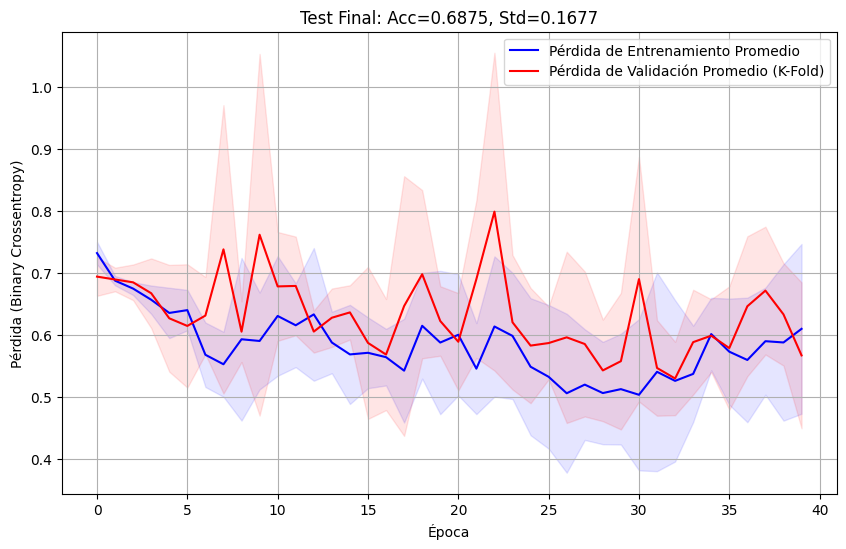

In [10]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    # Aquí puedes modificar 128 a 32, cambiar el recurrent_dropout, etc.
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(128, return_sequences=False)) 
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Compilamos el modelo
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model

# --- EJECUCIÓN DEL EXPERIMENTO ---
# Asume que X_train y y_train están cargados.

mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)

### Validadicón cruzada ajustando parámetros

Dropout de 20%, 32 unidades 

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 0.8750 | Pérdida: 0.6260
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.8125 | Pérdida: 0.6261
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.3750 | Pérdida: 0.7123
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.5625 | Pérdida: 0.6854
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 0.7500 | Pérdida: 0.6281
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.6750**
| Desviación Estándar de la Precisión: **0.1829**


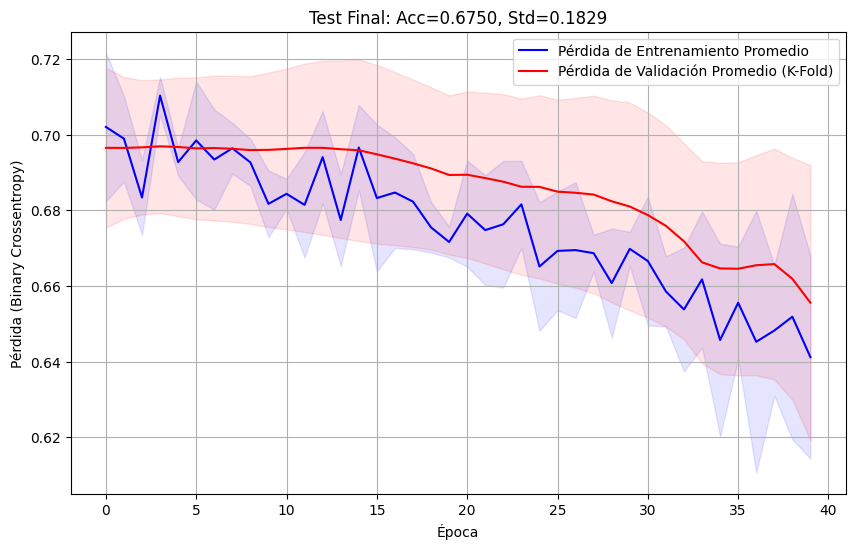

In [11]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(32, return_sequences=False)) # <-- ¡Dropout recurrente añadido!
    
    # 3. Dropout (Regularización después de la LSTM)
    model.add(Dropout(0.2)) 
    model.add(Dense(32, activation='relu'))
    # 5. Dropout Opcional (Regularización después de la Densa)
    model.add(Dropout(0.2)) 
    model.add(Dense(1, activation='sigmoid'))

    custom_adam = Adam(learning_rate=0.0001) # <-- Nueva Tasa de Aprendizaje

    model.compile(
        loss='binary_crossentropy',
        optimizer=custom_adam,
        metrics=['accuracy']
    )
    return model

mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)

Los resultados de accuracy y la desvicion son practicamente iguales que son dropout y con 128 unidades en vez de 32

### LSTM Simple sin videos ruidosos

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.losses import binary_crossentropy

# --- A. Entrenar un Modelo Único para el Análisis ---

# Re-entrenamos el modelo con todos los datos de entrenamiento (X_train)
# para obtener un buen conjunto de pesos para el análisis.
ANALYSIS_EPOCHS = 40  # Puedes usar 40 o el número de épocas que te dio el mejor resultado

print("Entrenando modelo para análisis de pérdida...")
analysis_model = create_lstm_model(timesteps, features)

# Entrenamos sin validación aquí, ya que el objetivo es el análisis de pérdida en X_train.
analysis_model.fit(
    X_train, y_train,
    epochs=ANALYSIS_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)

# --- B. Calcular la Pérdida por Muestra en X_train ---

print("Calculando la pérdida individual por muestra...")
# 1. Obtener las predicciones del modelo en el conjunto de entrenamiento (X_train)
y_pred_proba = analysis_model.predict(X_train)

# Convertir y_train de la forma (80,) a la forma (80, 1) para que coincida con la predicción (80, 1).
y_train_reshaped = np.expand_dims(y_train, axis=-1)

# 2. Convertir a tensores para el cálculo de la pérdida
y_train_tf = tf.convert_to_tensor(y_train_reshaped, dtype=tf.float32) # <-- Usamos el array reformateado
y_pred_tf = tf.convert_to_tensor(y_pred_proba, dtype=tf.float32)

# 3. Calcular la Binary Crossentropy (pérdida) para cada muestra
# Esto ya no generará error ya que ambas variables son ahora 2D.
losses_per_sample = binary_crossentropy(y_train_tf, y_pred_tf)
losses_np = losses_per_sample.numpy()

# --- C. Identificar los Índices Ruidosos ---

# 1. Definir el porcentaje de ruido a buscar (ej: el 5% de las muestras con mayor pérdida)
PERCENTAJE_RUIDO = 0.05
num_total_samples = len(X_train)
num_noisy_samples = int(num_total_samples * PERCENTAJE_RUIDO)

# 2. Obtener los índices de las muestras ordenadas por pérdida (mayor a menor)
# np.argsort devuelve los índices que ordenarían el array
noisy_indices = np.argsort(losses_np)[::-1] # [::-1] invierte el orden para obtener los mayores primero

# 3. Seleccionar los top N índices más ruidosos
top_noisy_indices_X_train = noisy_indices[:num_noisy_samples]


# --- D. Resultados ---

print("\n" + "="*50)
print(f"ANÁLISIS DE RUIDO COMPLETADO ({num_total_samples} muestras en X_train)")
print(f"Se han identificado los {num_noisy_samples} índices ({PERCENTAJE_RUIDO*100}%) más ruidosos.")
print("="*50)

print("Top 5% de Muestras Ruidosas (Índice y Pérdida):")

# Imprimir los índices, su pérdida y la etiqueta real
for i in top_noisy_indices_X_train:
    print(f"Índice en X_train: {i} | Pérdida: {losses_np[i]:.4f} | Etiqueta Real: {y_train[i]}")

print("="*50)

Entrenando modelo para análisis de pérdida...
Calculando la pérdida individual por muestra...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step

ANÁLISIS DE RUIDO COMPLETADO (80 muestras en X_train)
Se han identificado los 4 índices (5.0%) más ruidosos.
Top 5% de Muestras Ruidosas (Índice y Pérdida):
Índice en X_train: 46 | Pérdida: 0.7967 | Etiqueta Real: 1
Índice en X_train: 51 | Pérdida: 0.7606 | Etiqueta Real: 1
Índice en X_train: 36 | Pérdida: 0.7600 | Etiqueta Real: 1
Índice en X_train: 43 | Pérdida: 0.7361 | Etiqueta Real: 1


In [13]:
import numpy as np

# Índices identificados como ruidosos (de mayor a menor pérdida)
# NOTA: Debes usar los índices de tu array X_train actual
indices_a_eliminar = top_noisy_indices_X_train

print(f"Número de muestras antes de la eliminación: {len(X_train)}")

# 1. Eliminar las filas correspondientes de X_train
# axis=0 indica que se eliminan filas.
X_train_limpio = np.delete(X_train, indices_a_eliminar, axis=0)

# 2. Eliminar las etiquetas correspondientes de y_train
y_train_limpio = np.delete(y_train, indices_a_eliminar, axis=0)

print(f"Número de muestras después de la eliminación: {len(X_train_limpio)}")

# Asignar los arrays limpios de vuelta a las variables de entrenamiento
X_train = X_train_limpio
y_train = y_train_limpio

Número de muestras antes de la eliminación: 80
Número de muestras después de la eliminación: 76


In [14]:
model = Sequential()
model.add(Masking(mask_value=0., input_shape=(timesteps, features)))  # ignorar padding
model.add(LSTM(64, return_sequences=False))  # 64 unidades LSTM, solo devolvemos la última salida
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))    # salida binaria

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=35,
    batch_size=16
)

Epoch 1/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - accuracy: 0.5500 - loss: 0.7158 - val_accuracy: 0.6250 - val_loss: 0.6249
Epoch 2/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7000 - loss: 0.6600 - val_accuracy: 0.7500 - val_loss: 0.6317
Epoch 3/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.8000 - loss: 0.6218 - val_accuracy: 0.8125 - val_loss: 0.5850
Epoch 4/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8000 - loss: 0.5719 - val_accuracy: 0.7500 - val_loss: 0.5413
Epoch 5/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.8000 - loss: 0.5125 - val_accuracy: 0.8125 - val_loss: 0.4735
Epoch 6/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.8167 - loss: 0.4956 - val_accuracy: 0.6875 - val_loss: 0.6506
Epoch 7/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.7667 - loss: 0.4892 - val_accuracy: 0.8125 - val_loss: 0.4568
Epoch 8/35
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.7833 - loss: 0.4870 - val_accuracy: 0.7500 - val_loss: 0.5453


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.6000 - loss: 0.6347
Test Accuracy: 0.60


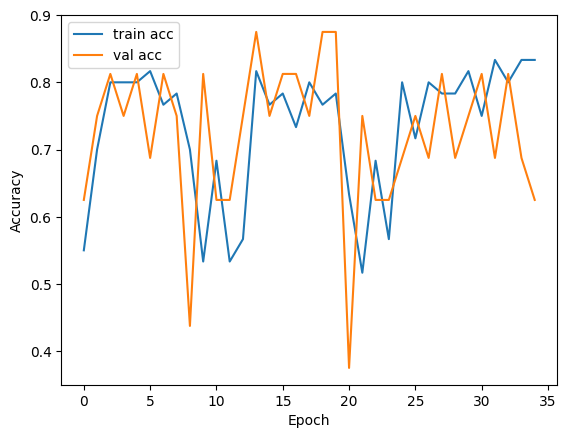

In [15]:

loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2f}")


plt.plot(history.history['accuracy'], label='train acc') # poner loss
plt.plot(history.history['val_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Al quitar las muestras, la LSTM simple ha empeorado 

### Validación cruzada sin videos ruidosos

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 0.8125 | Pérdida: 0.3486
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.6667 | Pérdida: 0.5785
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.7333 | Pérdida: 0.5835
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.8000 | Pérdida: 0.6699
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 0.8000 | Pérdida: 0.4998
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.7625**
| Desviación Estándar de la Precisión: **0.0554**


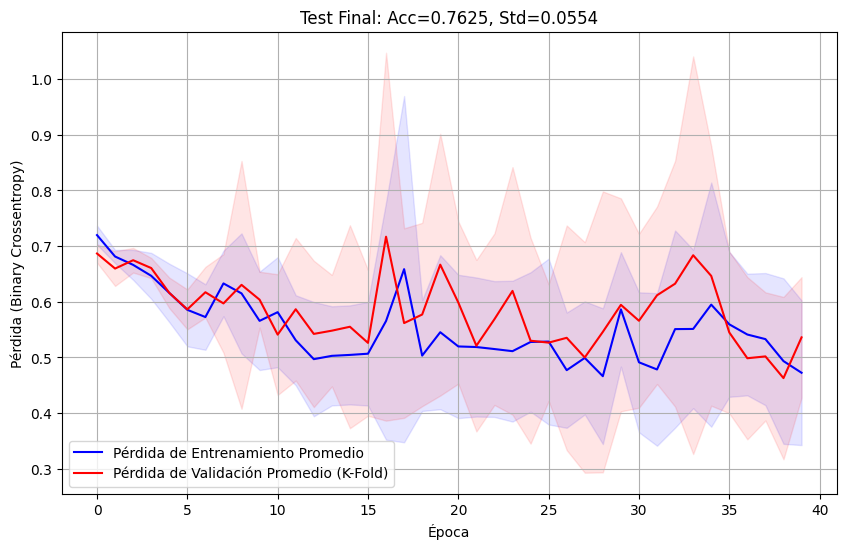

In [19]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    # Aquí puedes modificar 128 a 32, cambiar el recurrent_dropout, etc.
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(128, return_sequences=False)) 
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Compilamos el modelo
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model


mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)

Aqui obtenemos un mejor accuracy que el modelo con los videos ruidosos y obtenemos una desviación baja

### Validación cruzada ajustando parámetros sin videos ruidosos

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 0.8750 | Pérdida: 0.4790
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.8000 | Pérdida: 0.5586
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.7333 | Pérdida: 0.5914
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.7333 | Pérdida: 0.6606
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 0.8000 | Pérdida: 0.6252
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.7883**
| Desviación Estándar de la Precisión: **0.0526**


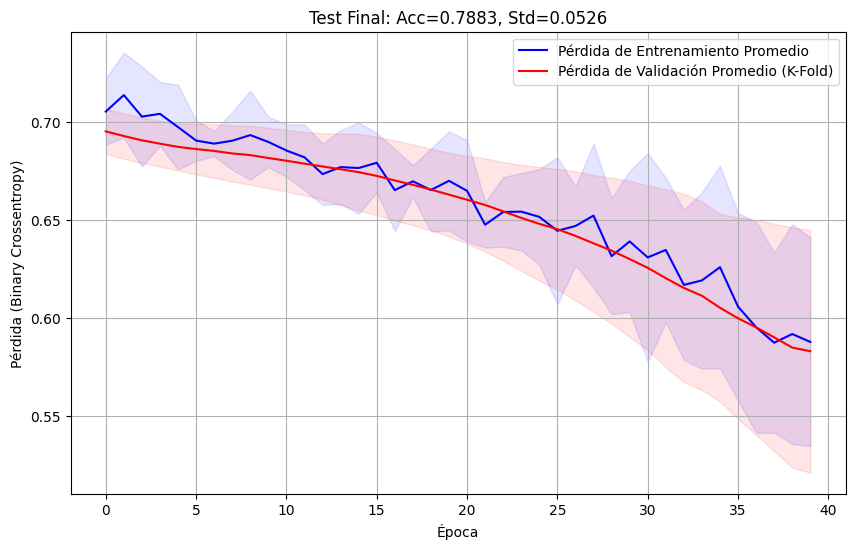

In [20]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(32, return_sequences=False)) # <-- ¡Dropout recurrente añadido!
    
    # 3. Dropout (Regularización después de la LSTM)
    model.add(Dropout(0.2)) 
    model.add(Dense(32, activation='relu'))
    # 5. Dropout Opcional (Regularización después de la Densa)
    model.add(Dropout(0.2)) 
    model.add(Dense(1, activation='sigmoid'))
    
    custom_adam = Adam(learning_rate=0.0001) # <-- Nueva Tasa de Aprendizaje

    model.compile(
        loss='binary_crossentropy',
        optimizer=custom_adam,
        metrics=['accuracy']
    )
    return model

mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)

Si mantenemos 32 unidades y aplicamos dropout y reducimos la tasa de aprendizaje obtenemos los mejores resultados hasta el momento, también se ve representado en la gráfica.  

(Los resultados han empeorado si dejamos la tasa de aprendizaje predefinida y mantenemos el dropout al 20% y bajamos a 32 unidades (en vez de usar 128))

## Ángulos articulares como datos de entrada del modelo

### Carga de datos

In [21]:
# ## Coordenadas de ángulos articulares como datos de entrada del modelo
X_correct = np.load('../Data/Processed/correct_push_ups_angles.npy')
X_incorrect = np.load('../Data/Processed/wrong_push_ups_angles.npy')

# Creamos etiquetas
X = np.vstack((X_correct, X_incorrect))
y = np.array([1]*X_correct.shape[0] + [0]*X_incorrect.shape[0])  

In [22]:
# Dividimos en conjunto de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [23]:
# Definimos y entrenamos el modelo LSTM
timesteps = X_train.shape[1]  # 160 frames (numero de frames por secuencia)
features = X_train.shape[2]   # 66 valores por frame


### LSTM Simple

In [24]:
model = Sequential()
model.add(Masking(mask_value=0., input_shape=(timesteps, features)))  # ignorar padding
model.add(LSTM(64, return_sequences=False))  # 64 unidades LSTM, solo devolvemos la última salida
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))    # salida binaria

# Compilamos y entrenamos el modelo
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=16
)


Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.6250 - loss: 0.6766 - val_accuracy: 0.6250 - val_loss: 0.6643
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.6250 - loss: 0.6506 - val_accuracy: 0.8125 - val_loss: 0.6314
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.7500 - loss: 0.6187 - val_accuracy: 0.8125 - val_loss: 0.5872
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8125 - loss: 0.5860 - val_accuracy: 0.8750 - val_loss: 0.5596
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8438 - loss: 0.5708 - val_accuracy: 0.9375 - val_loss: 0.5361
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8750 - loss: 0.5430 - val_accuracy: 0.9375 - val_loss: 0.5251
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8906 - loss: 0.5277 - val_accuracy: 0.9375 - val_loss: 0.4739
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.8125 - loss: 0.5231 - val_accuracy: 0.9375 - val_loss: 0.4624


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.9000 - loss: 0.2378
Test Accuracy: 0.90


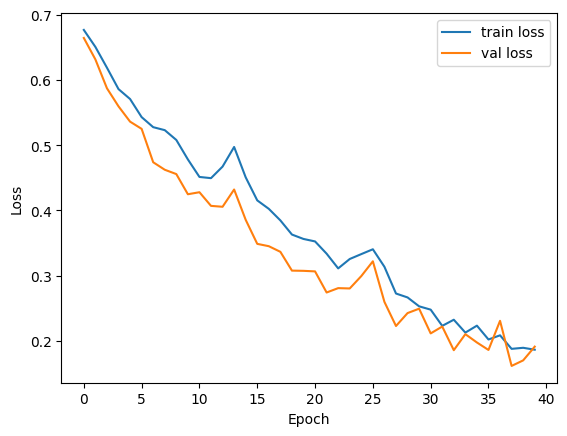

In [25]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2f}")


plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Vemos que los resultados de la LSTM simple ya son considerablemente mejores, el accuracy esta entre el 80 y el 90 porciento 

### Validación cruzada 

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 0.8125 | Pérdida: 0.4434
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 1.0000 | Pérdida: 0.1164
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.9375 | Pérdida: 0.2279
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.9375 | Pérdida: 0.1966
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 1.0000 | Pérdida: 0.1475
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.9375**
| Desviación Estándar de la Precisión: **0.0685**


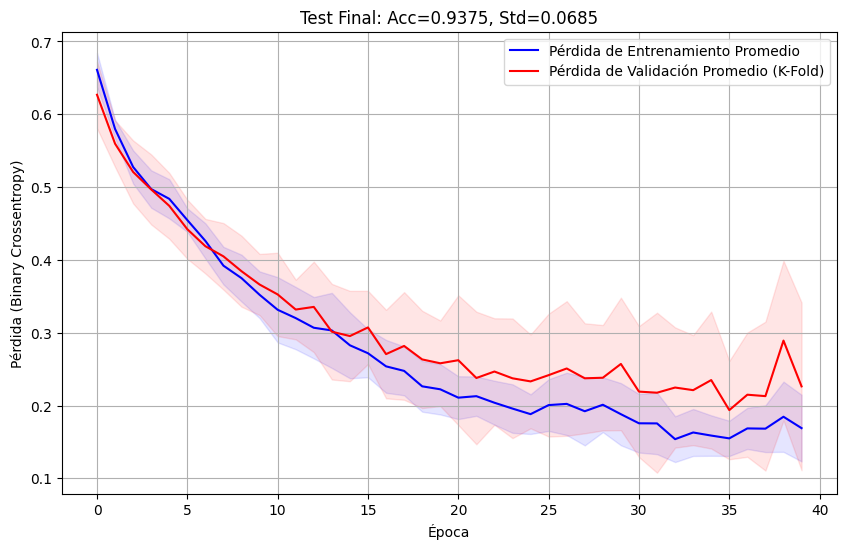

In [26]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    # Aquí puedes modificar 128 a 32, cambiar el recurrent_dropout, etc.
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(128, return_sequences=False)) 
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Compilamos el modelo
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model


mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)

Los resultados son muy buenos, obtenemos una precision del 93.75%

### Validación cruzada ajustando parámetros 

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 0.8125 | Pérdida: 0.4394
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.9375 | Pérdida: 0.3215
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.9375 | Pérdida: 0.4904
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.8750 | Pérdida: 0.4528
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 0.9375 | Pérdida: 0.3709
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.9000**
| Desviación Estándar de la Precisión: **0.0500**


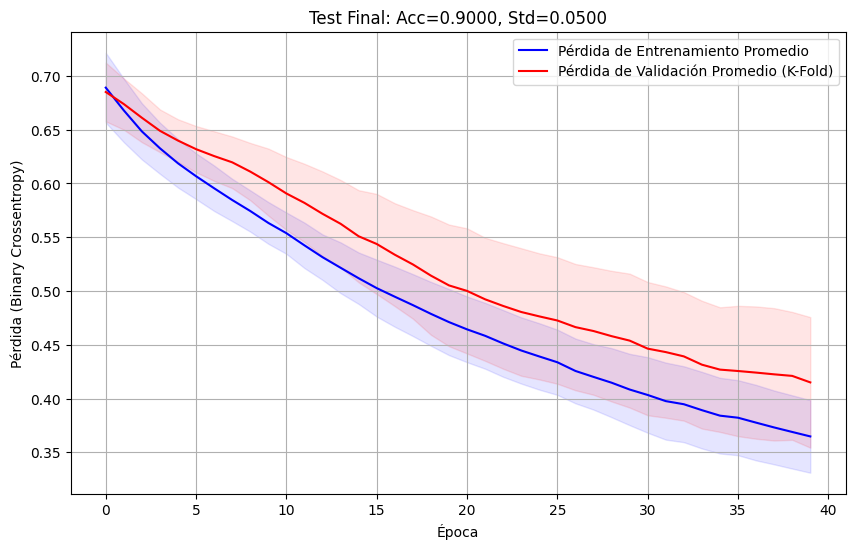

In [27]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    # Aquí puedes modificar 128 a 32, cambiar el recurrent_dropout, etc.
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(128, return_sequences=False)) 
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    custom_adam = Adam(learning_rate=0.0001) # <-- Nueva Tasa de Aprendizaje

    # Compilamos el modelo
    model.compile(
        loss='binary_crossentropy',
        optimizer=custom_adam,
        metrics=['accuracy']
    )

    return model


mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)

### LSTM Simple sin videos ruidosos 

In [28]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.losses import binary_crossentropy

# --- A. Entrenar un Modelo Único para el Análisis ---

# Re-entrenamos el modelo con todos los datos de entrenamiento (X_train)
# para obtener un buen conjunto de pesos para el análisis.
ANALYSIS_EPOCHS = 40  # Puedes usar 40 o el número de épocas que te dio el mejor resultado

print("Entrenando modelo para análisis de pérdida...")
analysis_model = create_lstm_model(timesteps, features)

# Entrenamos sin validación aquí, ya que el objetivo es el análisis de pérdida en X_train.
analysis_model.fit(
    X_train, y_train,
    epochs=ANALYSIS_EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=0
)

# --- B. Calcular la Pérdida por Muestra en X_train ---

print("Calculando la pérdida individual por muestra...")
# 1. Obtener las predicciones del modelo en el conjunto de entrenamiento (X_train)
y_pred_proba = analysis_model.predict(X_train)

# Convertir y_train de la forma (80,) a la forma (80, 1) para que coincida con la predicción (80, 1).
y_train_reshaped = np.expand_dims(y_train, axis=-1)

# 2. Convertir a tensores para el cálculo de la pérdida
y_train_tf = tf.convert_to_tensor(y_train_reshaped, dtype=tf.float32) # <-- Usamos el array reformateado
y_pred_tf = tf.convert_to_tensor(y_pred_proba, dtype=tf.float32)

# 3. Calcular la Binary Crossentropy (pérdida) para cada muestra
# Esto ya no generará error ya que ambas variables son ahora 2D.
losses_per_sample = binary_crossentropy(y_train_tf, y_pred_tf)
losses_np = losses_per_sample.numpy()

# --- C. Identificar los Índices Ruidosos ---

# 1. Definir el porcentaje de ruido a buscar (ej: el 5% de las muestras con mayor pérdida)
PERCENTAJE_RUIDO = 0.05
num_total_samples = len(X_train)
num_noisy_samples = int(num_total_samples * PERCENTAJE_RUIDO)

# 2. Obtener los índices de las muestras ordenadas por pérdida (mayor a menor)
# np.argsort devuelve los índices que ordenarían el array
noisy_indices = np.argsort(losses_np)[::-1] # [::-1] invierte el orden para obtener los mayores primero

# 3. Seleccionar los top N índices más ruidosos
top_noisy_indices_X_train = noisy_indices[:num_noisy_samples]


# --- D. Resultados ---

print("\n" + "="*50)
print(f"ANÁLISIS DE RUIDO COMPLETADO ({num_total_samples} muestras en X_train)")
print(f"Se han identificado los {num_noisy_samples} índices ({PERCENTAJE_RUIDO*100}%) más ruidosos.")
print("="*50)

print("Top 5% de Muestras Ruidosas (Índice y Pérdida):")

# Imprimir los índices, su pérdida y la etiqueta real
for i in top_noisy_indices_X_train:
    print(f"Índice en X_train: {i} | Pérdida: {losses_np[i]:.4f} | Etiqueta Real: {y_train[i]}")

print("="*50)

Entrenando modelo para análisis de pérdida...
Calculando la pérdida individual por muestra...
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

ANÁLISIS DE RUIDO COMPLETADO (80 muestras en X_train)
Se han identificado los 4 índices (5.0%) más ruidosos.
Top 5% de Muestras Ruidosas (Índice y Pérdida):
Índice en X_train: 17 | Pérdida: 0.9586 | Etiqueta Real: 0
Índice en X_train: 14 | Pérdida: 0.8582 | Etiqueta Real: 0
Índice en X_train: 31 | Pérdida: 0.8403 | Etiqueta Real: 1
Índice en X_train: 70 | Pérdida: 0.7638 | Etiqueta Real: 0


In [29]:
import numpy as np

# Índices identificados como ruidosos (de mayor a menor pérdida)
# NOTA: Debes usar los índices de tu array X_train actual
indices_a_eliminar = top_noisy_indices_X_train

print(f"Número de muestras antes de la eliminación: {len(X_train)}")

# 1. Eliminar las filas correspondientes de X_train
# axis=0 indica que se eliminan filas.
X_train_limpio = np.delete(X_train, indices_a_eliminar, axis=0)

# 2. Eliminar las etiquetas correspondientes de y_train
y_train_limpio = np.delete(y_train, indices_a_eliminar, axis=0)

print(f"Número de muestras después de la eliminación: {len(X_train_limpio)}")

# Asignar los arrays limpios de vuelta a las variables de entrenamiento
X_train = X_train_limpio
y_train = y_train_limpio

Número de muestras antes de la eliminación: 80
Número de muestras después de la eliminación: 76


In [30]:
model = Sequential()
model.add(Masking(mask_value=0., input_shape=(timesteps, features)))  # ignorar padding
model.add(LSTM(64, return_sequences=False))  # 64 unidades LSTM, solo devolvemos la última salida
model.add(Dense(32, activation='relu'))
model.add(Dense(1, activation='sigmoid'))    # salida binaria

# Compilamos y entrenamos el modelo
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=16
)


Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.3667 - loss: 0.7233 - val_accuracy: 0.5625 - val_loss: 0.6798
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4833 - loss: 0.6925 - val_accuracy: 0.5625 - val_loss: 0.6421
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.6500 - loss: 0.6471 - val_accuracy: 0.8125 - val_loss: 0.5981
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.8333 - loss: 0.6113 - val_accuracy: 0.8125 - val_loss: 0.5663
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8833 - loss: 0.5791 - val_accuracy: 0.8750 - val_loss: 0.5393
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.9333 - loss: 0.5470 - val_accuracy: 0.9375 - val_loss: 0.5287
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - accuracy: 0.9000 - loss: 0.5163 - val_accuracy: 0.9375 - val_loss: 0.4722
Epoch 8/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8667 - loss: 0.4927 - val_accuracy: 0.8750 - val_loss: 0.4664


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9500 - loss: 0.3098
Test Accuracy: 0.95


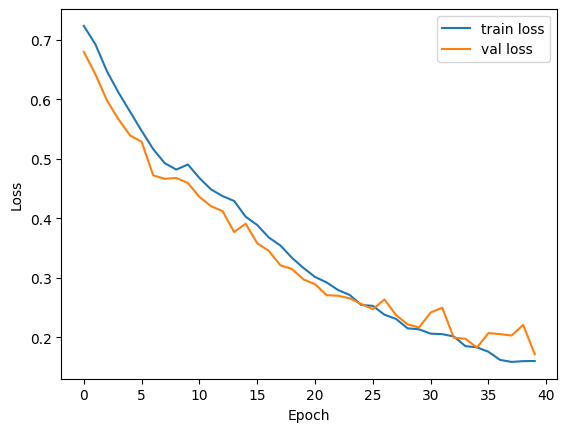

In [31]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {acc:.2f}")


plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

95% de accuracy

### Validación cruzada sin videos ruidosos

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 1.0000 | Pérdida: 0.0922
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.8667 | Pérdida: 0.4641
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.8667 | Pérdida: 0.3027
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.9333 | Pérdida: 0.1974
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 0.9333 | Pérdida: 0.1477
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.9200**
| Desviación Estándar de la Precisión: **0.0499**


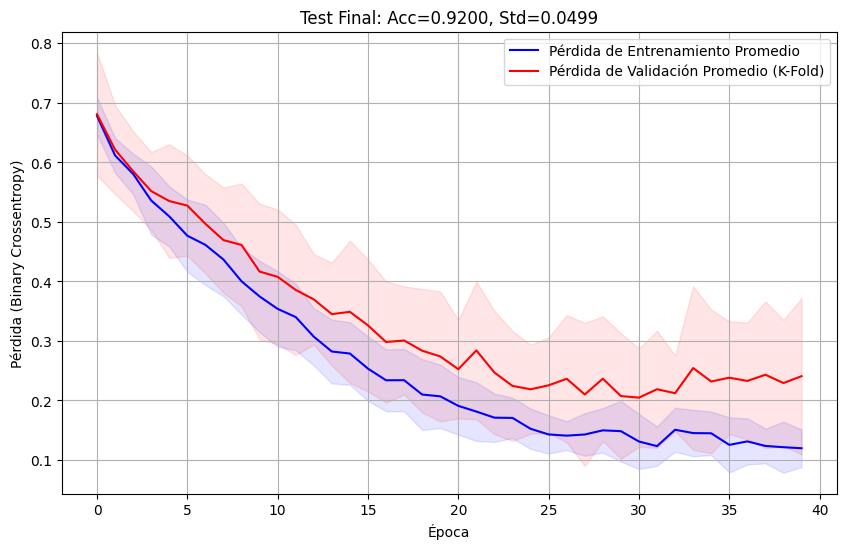

In [32]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    # Aquí puedes modificar 128 a 32, cambiar el recurrent_dropout, etc.
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(128, return_sequences=False)) 
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    # Compilamos el modelo
    model.compile(
        loss='binary_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )

    return model


mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)

Este es el mejor modelo de todo el fichero en cuanto a valores de accuracy, desviación y valores de pérdida. Sobreajusta un poco aunque de manera controlada. 

### Validación cruzada ajustando parámetros sin videos ruidosos

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 1.0000 | Pérdida: 0.3327
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.8667 | Pérdida: 0.3464
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 0.8667 | Pérdida: 0.4746
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.9333 | Pérdida: 0.3451
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 0.9333 | Pérdida: 0.3611
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.9200**
| Desviación Estándar de la Precisión: **0.0499**


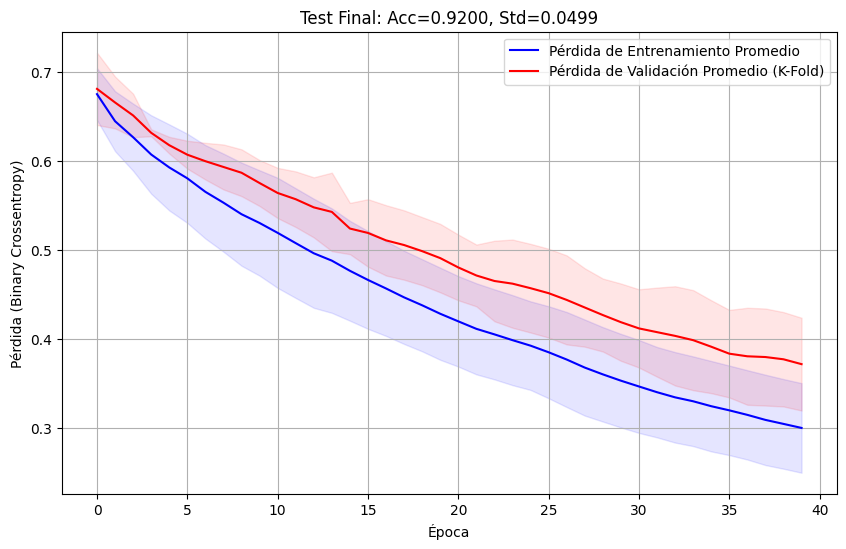

In [33]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    # Aquí puedes modificar 128 a 32, cambiar el recurrent_dropout, etc.
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(128, return_sequences=False)) 
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    custom_adam = Adam(learning_rate=0.0001) # <-- Nueva Tasa de Aprendizaje

    # Compilamos el modelo
    model.compile(
        loss='binary_crossentropy',
        optimizer=custom_adam,
        metrics=['accuracy']
    )

    return model

mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)

Vamos a probar a añadir dropout 

Iniciando la validación cruzada de 5 pliegues...
| Entrenando Pliegue 1/5...
| Precisión de Validación (Pliegue 1): 1.0000 | Pérdida: 0.3574
| Entrenando Pliegue 2/5...
| Precisión de Validación (Pliegue 2): 0.8667 | Pérdida: 0.4105
| Entrenando Pliegue 3/5...
| Precisión de Validación (Pliegue 3): 1.0000 | Pérdida: 0.4870
| Entrenando Pliegue 4/5...
| Precisión de Validación (Pliegue 4): 0.8000 | Pérdida: 0.4460
| Entrenando Pliegue 5/5...
| Precisión de Validación (Pliegue 5): 0.9333 | Pérdida: 0.4887
✅ Validación Cruzada Completada con 5 Pliegues.
| Precisión Media de Validación: **0.9200**
| Desviación Estándar de la Precisión: **0.0777**


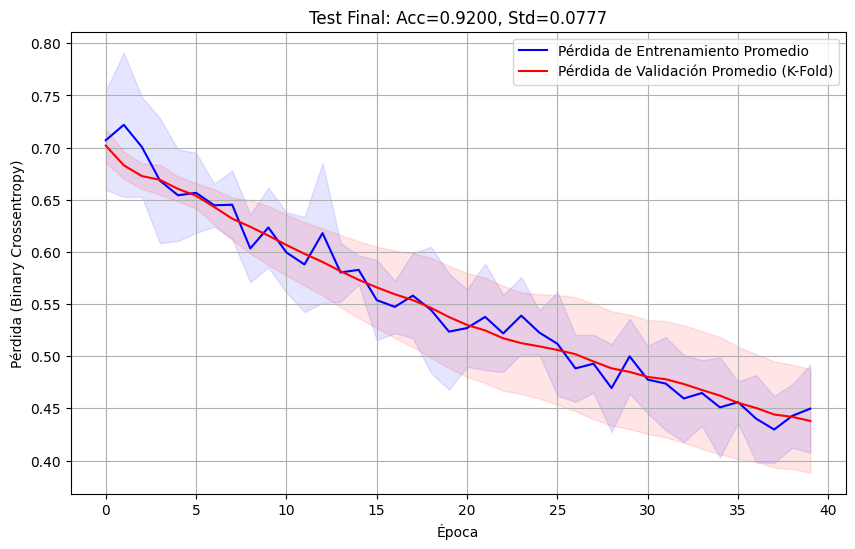

In [38]:
# --- DEFINICIÓN DE HIPERPARÁMETROS GENERALES ---
EPOCHS = 40
BATCH_SIZE = 16

# --- DEFINICIÓN DE LA ARQUITECTURA (Tu función, puedes copiarla y modificarla aquí) ---
def create_lstm_model(timesteps, features):
    # Aquí puedes modificar 128 a 32, cambiar el recurrent_dropout, etc.
    model = Sequential()
    model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
    model.add(LSTM(128, return_sequences=False)) 
    model.add(Dropout(0.2))
    model.add(Dense(32, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))

    custom_adam = Adam(learning_rate=0.0001) # <-- Nueva Tasa de Aprendizaje

    # Compilamos el modelo
    model.compile(
        loss='binary_crossentropy',
        optimizer=custom_adam,
        metrics=['accuracy']
    )

    return model

mean_acc, std_acc, histories = run_kfold_experiment(
    model_fn=create_lstm_model,
    X_train=X_train,
    y_train=y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

# --- GRAFICAR LOS RESULTADOS ---
plot_kfold_history(
    histories, 
    title=f'Test Final: Acc={mean_acc:.4f}, Std={std_acc:.4f}'
)